### 1. 목표 설정
- 보스턴 집값 데이터를 이용해서 회귀분석을 진행해보자.
- 특성곱을 이용해서 새로운 특성을 만들어보자.
- 규제 모델을 이용해서 모델의 복잡도를 제어해보자.

### 2. 데이터 수집
- csv파일 불러오기(보스턴 주택 데이터)

In [1]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# 데이터 불러오기
boston = pd.read_csv('./data/boston_housing.csv')

In [3]:
boston.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
# 필요없는 Unnamed 컬럼 삭제
boston.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [6]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


- 결측치 없음!

**특성정보 확인**
- CRIM : 범죄율
- INDUS : 비소매상업지역의 면적 비율 -> 도매상업지역의 면적
- NOX : 대기중 일산화질소의 농도
- RM : 주택당 방의 갯수
- LSTAT : 인구중 하위 계층의 비율
- B : 인구중 흑인의 비율
- PTRATIO : 학생 / 교사 비율
- ZN : 25,000 평방 피트를 초과한 거주지역의 비율
- CHAS : 찰스 강의 경계에 위치한 경우는 1, 아닌 경우는 0
- AGE : 1940년대 이전에 지어진 주택의 비율
- DIS : 직업센터의 거리
- TAX : 재산세율

**종속변수 확인**
- MEDV : 집 값

### 3. 데이터 전처리
- 결측치 없었다!
- 보스턴 주택 데이터는 학습용으로 제공된 데이터라 전처리가 필요없다.(데이터가 깔끔함)

### 4. 탐색적 데이터 분석
- 생략

### 5. 모델링 
- 데이터 분리(X_train, X_test, y_train, y_test)
- 모델 선정 및 학습 / 평가 / 예측

In [12]:
# 데이터 분리
# step.1 : 데이터를 분리하기 위한 모듈 불러오기
from sklearn.model_selection import train_test_split
# step.2 : 데이터 분리하기 (y(정답 데이터는 MEDV 컬럼))
# 현재 데이터의 상태부터 확인 -> 문제와 정답, train / test가 모두 한곳에 있는 데이터
# 문제와 정답을 분할해준 후 모듈을 돌려야함
X = boston.drop('MEDV', axis=1)
y = boston['MEDV']
# train_test_split 모듈 돌려보기
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state=8)
# step.3 : 데이터 분할 확인하기
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [13]:
# 분할된 데이터를 가지고 상관계수 확인하기
X_train.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.000000,-0.182937,0.376299,-0.060861,0.403308,-0.171128,0.340789,-0.362843,0.594251,0.545004,0.267743,-0.348000,0.415125
ZN,-0.182937,1.000000,-0.522421,-0.028334,-0.510633,0.355158,-0.558727,0.636020,-0.301522,-0.313148,-0.382122,0.179154,-0.432618
INDUS,0.376299,-0.522421,1.000000,0.036183,0.769310,-0.399291,0.643300,-0.711740,0.579389,0.725878,0.383825,-0.355823,0.619686
CHAS,-0.060861,-0.028334,0.036183,1.000000,0.089168,0.054014,0.071898,-0.090506,-0.019416,-0.060153,-0.174327,0.046020,-0.054811
NOX,0.403308,-0.510633,0.769310,0.089168,1.000000,-0.330699,0.713332,-0.764739,0.625537,0.683354,0.222476,-0.375495,0.622120
RM,-0.171128,0.355158,-0.399291,0.054014,-0.330699,1.000000,-0.258584,0.221348,-0.179420,-0.273715,-0.346742,0.107636,-0.597224
AGE,0.340789,-0.558727,0.643300,0.071898,0.713332,-0.258584,1.000000,-0.717366,0.456727,0.509456,0.283653,-0.266401,0.609375
DIS,-0.362843,0.636020,-0.711740,-0.090506,-0.764739,0.221348,-0.717366,1.000000,-0.491937,-0.543658,-0.245896,0.293658,-0.503820
RAD,0.594251,-0.301522,0.579389,-0.019416,0.625537,-0.179420,0.456727,-0.491937,1.000000,0.894749,0.451842,-0.459237,0.465304
TAX,0.545004,-0.313148,0.725878,-0.060153,0.683354,-0.273715,0.509456,-0.543658,0.894749,1.000000,0.460166,-0.449736,0.536399


<Axes: >

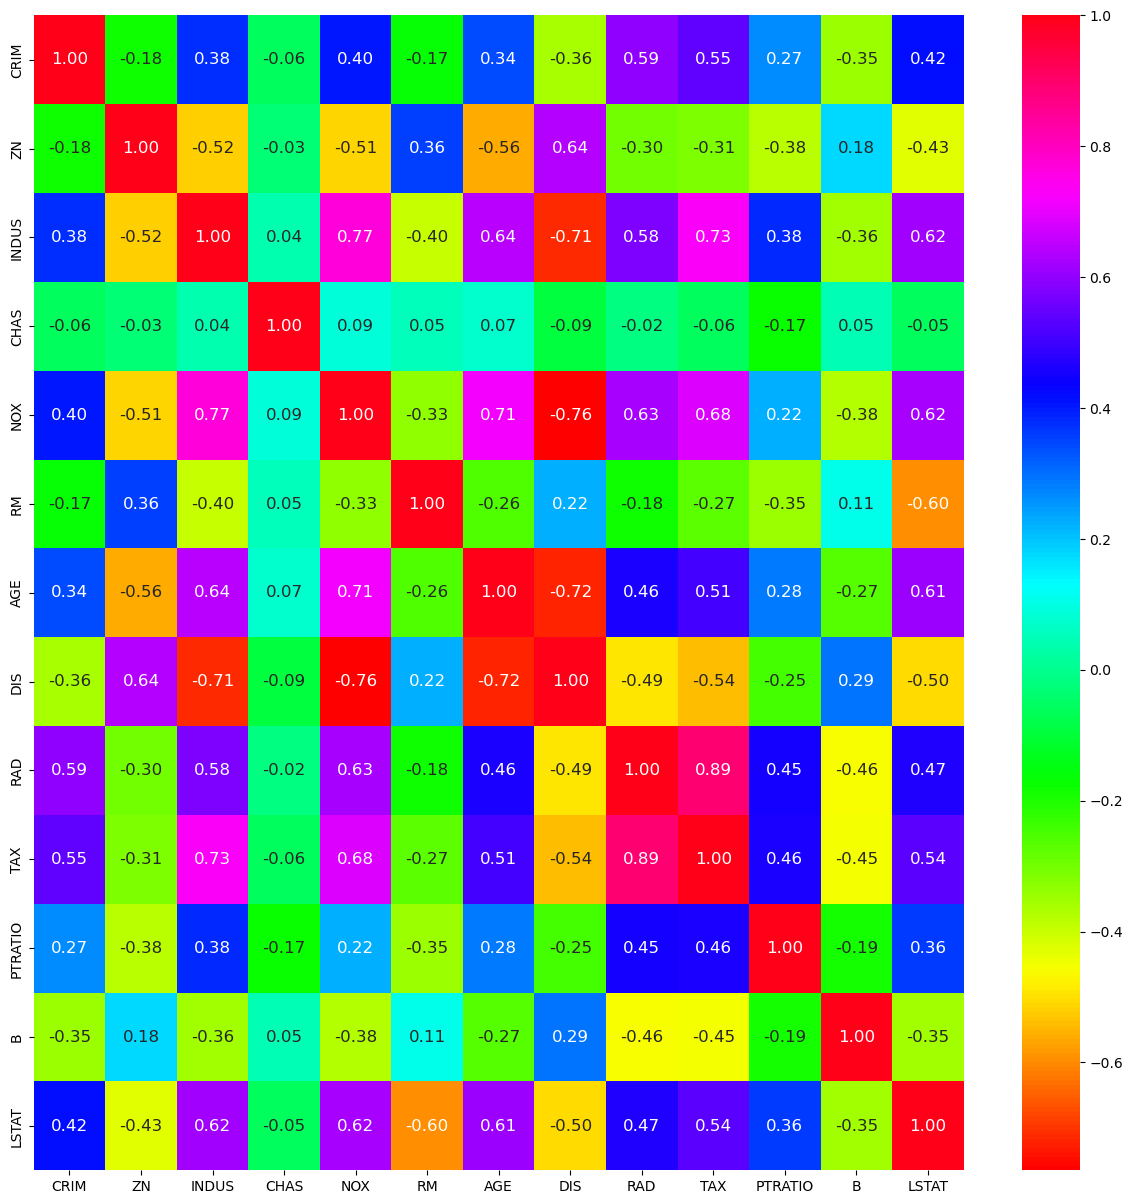

In [24]:
# 상관계수를 히트맵으로 출력
plt.figure(figsize=(15,15))

sns.heatmap(data = X_train.corr(),
            annot = True,            # 히트맵 내부에 글씨 출력 
            annot_kws={'size' : 12}, # 내부 글씨의 옵션(글씨의 크기)
            fmt = '.2f',             # 소숫점 자리 출력
            cmap = 'hsv'           # 히트맵의 색상
           )

In [29]:
# 선형 회귀 모델 사용하기
# Step.1 : 모델 import
from sklearn.linear_model import LinearRegression

In [33]:
# Step.2 : 모델 객체 생성
linear_model = LinearRegression()

In [34]:
# Step.3 : 모델 학습
linear_model.fit(X_train, y_train)

LinearRegression()

In [35]:
# Step.4 : 교차 검증
from sklearn.model_selection import cross_val_score

In [36]:
result = cross_val_score(linear_model, X_train, y_train, cv=5)

In [37]:
print(result)
print(result.mean())

[0.71475064 0.72476875 0.73085762 0.70688737 0.58341273]
0.6921354224035877


In [39]:
# 가중치 w값 확인해보기
linear_model.coef_

array([-1.08934120e-01,  5.31327453e-02,  2.34402817e-02,  2.48890273e+00,
       -1.22283083e+01,  3.88090530e+00, -8.65043560e-03, -1.39279889e+00,
        2.72090186e-01, -1.11667903e-02, -9.34401294e-01,  1.05766056e-02,
       -5.59850621e-01])

In [40]:
# 편향 b값 확인해보기
linear_model.intercept_

32.75619254730957

In [41]:
# 정답 예측
pre = linear_model.predict(X_test)
pre

array([19.36667199, 10.90135199, 38.22183643, 27.23008993, 40.86360853,
       27.462814  , 10.70895753, 36.33985245, 29.06780771, 34.65889684,
       13.06383643,  7.48552506, 15.30594202, 24.25609261, 15.7326924 ,
       28.85469028, 23.04674454, 22.4756561 , 21.13184502,  7.04408666,
       21.2118773 , 25.79184486, 30.52378626, 33.20341621, 28.66897069,
       35.44676805,  5.18094668, 14.36500631, 25.3635775 , 23.47314327,
       34.76079769, 18.53634825, 19.3854543 , 22.62515352, 25.72569699,
       27.00326966, 32.77697248, 25.60236289, 14.17206244, 14.13144421,
       21.53407601, 22.06013745, 36.0022969 , 35.29690286, 23.51437086,
       19.59457401, 19.9447559 , 21.21333233, 25.9417255 , 24.31696286,
       20.3417074 , 16.57330724, 32.43896087, 16.28495814, 22.30364436,
       24.79835447, 20.81794378,  5.29117863, 20.08017474, 28.56185743,
       24.7867144 , 21.73890171, 20.53304151,  8.69947126, 13.85691136,
       17.77498272, 12.76563098, 20.30967384, 35.36378927, 35.64

- 회귀 평가 지표를 이용해서, 모델을 평가해보자.
- MSE, MAE, RMSE, R2스코어

In [42]:
# 평가지표 import 
# sklearn.metrics : 평가지표들이 모여있는 곳
from sklearn.metrics import mean_squared_error  # 평균 제곱 오차
from sklearn.metrics import mean_absolute_error # 평균 절대 오차
from sklearn.metrics import r2_score            # r2 스코어

In [43]:
# MSE 사용하기 
mean_squared_error(pre, y_test)

23.716180926283414

In [45]:
# RMSE 사용하기
# 사이킷런 내부에서는 RMSE를 지원하지 않는다. -> 넘파이에 있는 sqrt
np.sqrt(mean_squared_error(pre, y_test))

4.869926172570115

In [46]:
# MAE 사용하기
mean_absolute_error(pre, y_test)

3.453292655262321

In [47]:
# r2스코어 사용하기
r2_score(pre, y_test)

0.6570277457568257

In [48]:
# score함수 사용해보기
linear_model.score(X_test, y_test)

0.7080516940202766